# S10 – Компьютерное зрение (PyTorch): CNN с нуля

В S08-S09 собрали устойчивый `train/eval`-цикл на PyTorch. В S10 меняем **тип модели** и **предобработку данных**: переходим от MLP к **свёрточным сетям (CNN)**.

Идея ноутбука: собрать простую CNN руками, понять, что происходит с `shape`, и сравнить CNN с MLP-базлайном на картинках.

## 0. План

К концу ноутбука надо уметь:

1) Подготовить датасет изображений (CIFAR-10) и корректную нормализацию.
2) Собрать простую CNN на `nn.Conv2d`/`nn.MaxPool2d` и понимать изменение размеров тензоров.
3) Запустить обучение с уже знакомым `fit()` и сравнить CNN с MLP-базлайном.

Можно включить **FAST_MODE**: небольшой поднабор данных и мало эпох, чтобы всё быстро работало на CPU.

## 1. Импорты и общие настройки

In [1]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cuda


## 2. Данные: CIFAR-10

CIFAR-10: 10 классов, изображения 32×32 RGB.

Нормализация: используем стандартные `mean/std` для CIFAR-10 (можно и посчитать вручную).

In [3]:
# CIFAR-10 mean/std (часто используемые значения)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

def load_cifar10(data_dir: str = DATA_DIR):
    tf_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    ds_train_full = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=tf_train)
    ds_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full, ds_test = load_cifar10()
class_names = ds_train_full.classes
print("Train full:", len(ds_train_full))
print("Test:", len(ds_test))
print("Classes:", class_names)

100%|██████████| 170M/170M [00:03<00:00, 46.7MB/s]


Train full: 50000
Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([128, 3, 32, 32]) torch.float32
y: torch.Size([128]) torch.int64


### Визуализация: несколько примеров

В ноутбуке храним данные в **нормализованном** виде. Чтобы показать картинки, делаем обратную денормализацию.

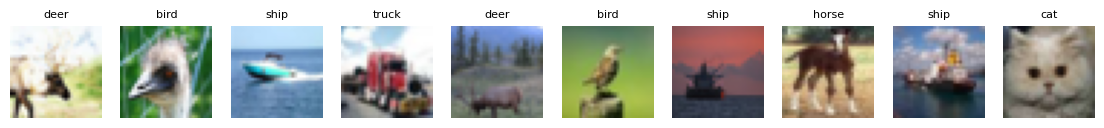

In [ ]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

## 3. Базовая точка: MLP на картинках

MLP видит картинку как вектор длины `32*32*3=3072`. Он **не использует локальную структуру** и быстро раздувается по числу параметров. Сделаем MLP-базлайн как контрольную точку.

In [6]:
INPUT_DIM = 32 * 32 * 3
NUM_CLASSES = 10

class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 1024, hidden2: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,C,H,W) -> (B, C*H*W)
        x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(mlp)
print("Trainable params:", count_params(mlp))

MLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)
Trainable params: 3676682


## 4. CNN: простая архитектура

Соберём минимальную CNN:
- несколько блоков `Conv2d + ReLU + MaxPool`,
- затем классификатор `Linear`.

Важно: понимать, что происходит с размерностями.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 620362


In [8]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 32, 32).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 32, 32]) Output logits: torch.Size([2, 10])


## 5. Цикл обучения

Используем `CrossEntropyLoss` и базовый `fit()` с историей.

In [9]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

## 6. Эксперимент: MLP vs CNN

Важно: это **демонстрация**, а не погоня за качеством. Сравниваем, насколько CNN лучше использует структуру изображений.

Одинаковые условия: один и тот же датасет, одна и та же функция потерь, примерно одинаковое число эпох.


Experiment MLP_baseline | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 3676682
Epoch 01/12 | train loss 1.6853, acc 0.400 | val loss 1.5510, acc 0.453 | 12.4s
Epoch 02/12 | train loss 1.4771, acc 0.477 | val loss 1.4789, acc 0.482 | 12.2s
Epoch 03/12 | train loss 1.3668, acc 0.516 | val loss 1.4580, acc 0.486 | 12.2s
Epoch 04/12 | train loss 1.2887, acc 0.543 | val loss 1.4395, acc 0.496 | 12.2s
Epoch 05/12 | train loss 1.2056, acc 0.572 | val loss 1.4692, acc 0.499 | 12.8s
Epoch 06/12 | train loss 1.1242, acc 0.600 | val loss 1.4516, acc 0.512 | 11.8s
Epoch 07/12 | train loss 1.0546, acc 0.626 | val loss 1.4360, acc 0.522 | 11.7s
Epoch 08/12 | train loss 0.9790, acc 0.650 | val loss 1.4986, acc 0.522 | 15.3s
Epoch 09/12 | train loss 0.9082, acc 0.673 | val loss 1.5826, acc 0.518 | 11.7s
Epoch 10/12 | train loss 0.8519, acc 0.698 | val loss 1.6111, acc 0.516 | 11.7s
Epoch 11/12 | train loss 0.7775, acc 0.721 | val loss 1.6926, acc 0.513 | 11.6s
Epoch 12/12 | train loss 0.7242

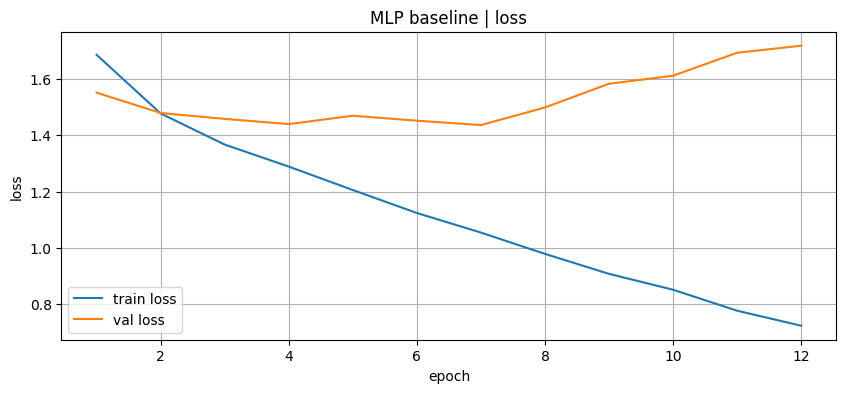

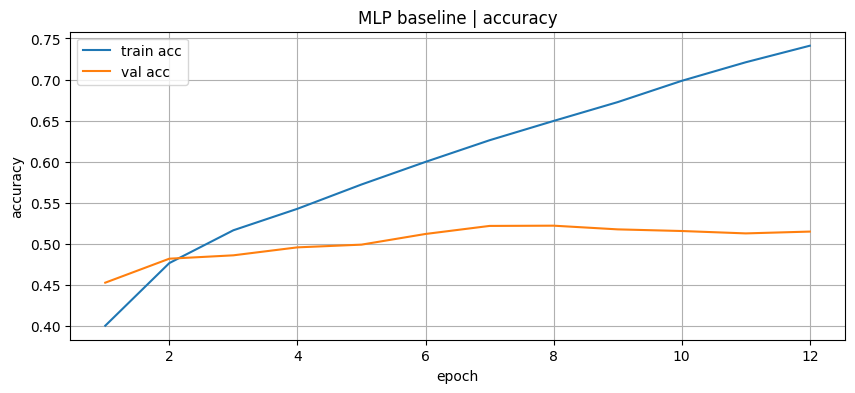


Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 620362
Epoch 01/12 | train loss 1.4535, acc 0.476 | val loss 1.1234, acc 0.600 | 12.3s
Epoch 02/12 | train loss 1.0251, acc 0.639 | val loss 0.9431, acc 0.669 | 12.4s
Epoch 03/12 | train loss 0.8294, acc 0.708 | val loss 0.8556, acc 0.701 | 12.7s
Epoch 04/12 | train loss 0.6992, acc 0.754 | val loss 0.7882, acc 0.722 | 12.3s
Epoch 05/12 | train loss 0.5909, acc 0.793 | val loss 0.7537, acc 0.735 | 12.1s
Epoch 06/12 | train loss 0.4890, acc 0.830 | val loss 0.7531, acc 0.749 | 12.0s
Epoch 07/12 | train loss 0.4033, acc 0.860 | val loss 0.8271, acc 0.734 | 11.9s
Epoch 08/12 | train loss 0.3205, acc 0.888 | val loss 0.8525, acc 0.738 | 12.5s
Epoch 09/12 | train loss 0.2426, acc 0.915 | val loss 0.9508, acc 0.742 | 12.5s
Epoch 10/12 | train loss 0.1819, acc 0.937 | val loss 0.9824, acc 0.744 | 12.9s
Epoch 11/12 | train loss 0.1293, acc 0.955 | val loss 1.1076, acc 0.742 | 12.8s
Epoch 12/12 | train loss 0.1077, a

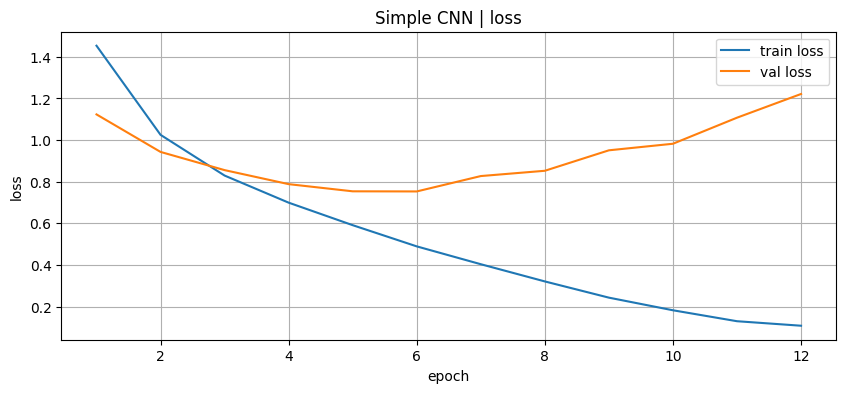

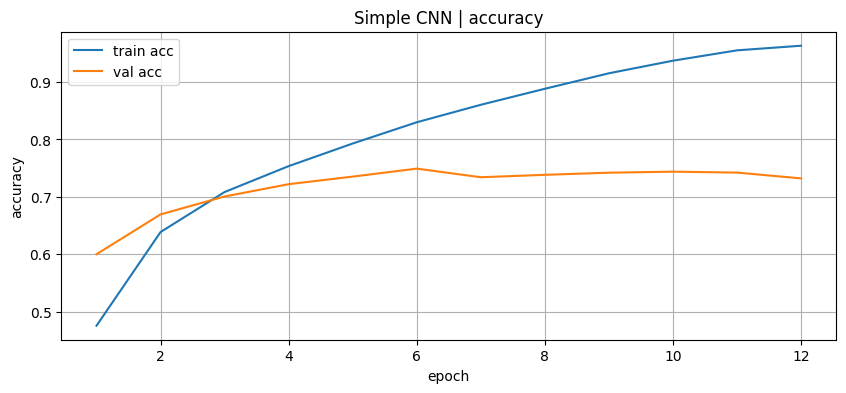

In [10]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

res_mlp = run_experiment("MLP_baseline", MLP(INPUT_DIM, NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_mlp["history"], title="MLP baseline")

res_cnn = run_experiment("CNN_simple", SimpleCNN(NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn["history"], title="Simple CNN")

### Быстрая проверка на test

Оценим качество лучших моделей на test-выборке.

In [11]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_mlp = accuracy_on_loader(res_mlp["model"], test_loader)
test_acc_cnn = accuracy_on_loader(res_cnn["model"], test_loader)

print("Test acc (MLP):", round(test_acc_mlp, 4))
print("Test acc (CNN):", round(test_acc_cnn, 4))

Test acc (MLP): 0.5101
Test acc (CNN): 0.7355


## 7. Итоги

- В MLP картинка превращается в вектор: связи «рядом по пикселям» теряются.
- CNN использует локальность и повторное использование фильтров, а значит меньше параметров и лучше обобщение.
- Инженерно цикл обучения практически не меняется: меняются данные и модель.

## Задания для самостоятельной работы

1) Добавьте **аугментации** (RandomCrop/Flip) и сравните кривые обучения.
2) Добавьте `BatchNorm2d` и/или `Dropout` в классификатор.
3) Подберите LR (например 3e-4, 1e-3, 3e-3) и посмотрите на устойчивость/сходимость.
4) Сделайте `EarlyStopping` (если уже реализовывали ранее) и сравните результат.